In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

DATA_PATH     = "/content/bank (1).csv"
TARGET        = "deposit"
SCALER        = "standard"
DROP_DURATION = False
TEST_SIZE     = 0.2
RANDOM_STATE  = 42

## 1.İlkin məlumatları nəzərdən keçirmək.

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.info()
display(df.head())

Shape: (11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
display(df.describe().round(2))

,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


## 2.Gizli problemləri aşkar etmək.


In [6]:
print("Real NaN per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "none")

unknown_counts = (df == "unknown").sum()
report = pd.DataFrame({"unknown_count": unknown_counts,
                       "unknown_pct": (unknown_counts / len(df) * 100).round(2)})
print("\nHidden missing values ('unknown'):")
display(report[report["unknown_count"] > 0])

print("Duplicate rows:", df.duplicated().sum())

text_cols = df.select_dtypes(exclude="number").columns.tolist()
for c in text_cols:
    bad = (df[c] != df[c].str.strip().str.lower()).sum()
    if bad: print("Text inconsistency in", c, ":", bad)
print("Text columns:", text_cols)

Real NaN per column:
none

Hidden missing values ('unknown'):


,unknown_count,unknown_pct
job,70,0.63
education,497,4.45
contact,2346,21.02
poutcome,8326,74.59


Duplicate rows: 0
Text columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [7]:
#Xüsusi rəqəmsal kodlar və şübhəli dəyərlər
print("pdays == -1      :", (df["pdays"] == -1).sum())
print("previous == 0    :", (df["previous"] == 0).sum())
print("both at once     :", ((df["pdays"] == -1) & (df["previous"] == 0)).sum())
print("smallest real pdays:", df.loc[df["pdays"] != -1, "pdays"].min())
print("negative balances:", (df["balance"] < 0).sum())
display(pd.crosstab(df["pdays"] == -1, df["poutcome"], rownames=["pdays == -1"]))

pdays == -1      : 8324
previous == 0    : 8324
both at once     : 8324
smallest real pdays: 1
negative balances: 688


poutcome,failure,other,success,unknown
pdays == -1,,,,
False,1228,537,1071,2
True,0,0,0,8324


## 3.Təmizləmə.

In [8]:
clean = df.copy()

#naməlum işi olan bir neçə sıranı buraxırıq
n_before = len(clean)
clean = clean[clean["job"] != "unknown"].copy()
print("Rows dropped (job unknown):", n_before - len(clean))

#naməlum dəyəri moda ilə əvəz edirik (moda naməlum dəyərlər nəzərə alınmadan hesablanır)
edu_mode = clean.loc[clean["education"] != "unknown", "education"].mode()[0]
print("Education mode used:", edu_mode)
clean["education"] = clean["education"].replace("unknown", edu_mode)

#-1'i 0 ilə əvəz edirik
#"əvvəllər heç vaxt əlaqə saxlanılmayıb" vəziyyəti poutcome == "unknown" vasitəsilə görünən qalır
clean.loc[clean["pdays"] == -1, "pdays"] = 0

clean = clean.reset_index(drop=True)
print("Clean shape:", clean.shape)
print("'unknown' left per column:")
print((clean == "unknown").sum()[(clean == "unknown").sum() > 0])

Rows dropped (job unknown): 70
Education mode used: secondary
Clean shape: (11092, 17)
'unknown' left per column:
contact     2336
poutcome    8275
dtype: int64


## 4.Məlumatların ilkin təhlili

,count,percent
deposit,,
no,5837,52.6
yes,5255,47.4


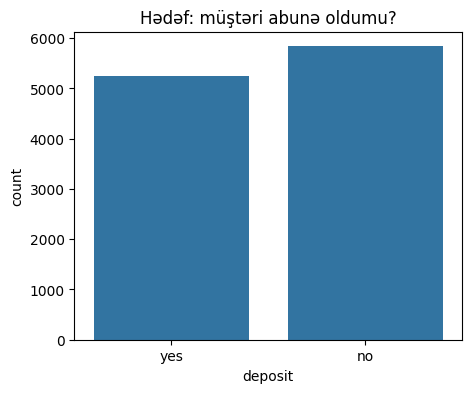

In [11]:
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

#Hədəf qalıq
counts = clean[TARGET].value_counts()
display(pd.DataFrame({"count": counts, "percent": (counts / len(clean) * 100).round(1)}))
plt.figure(figsize=(5, 4))
sns.countplot(data=clean, x=TARGET)
plt.title("Hədəf: müştəri abunə oldumu?")
plt.show()

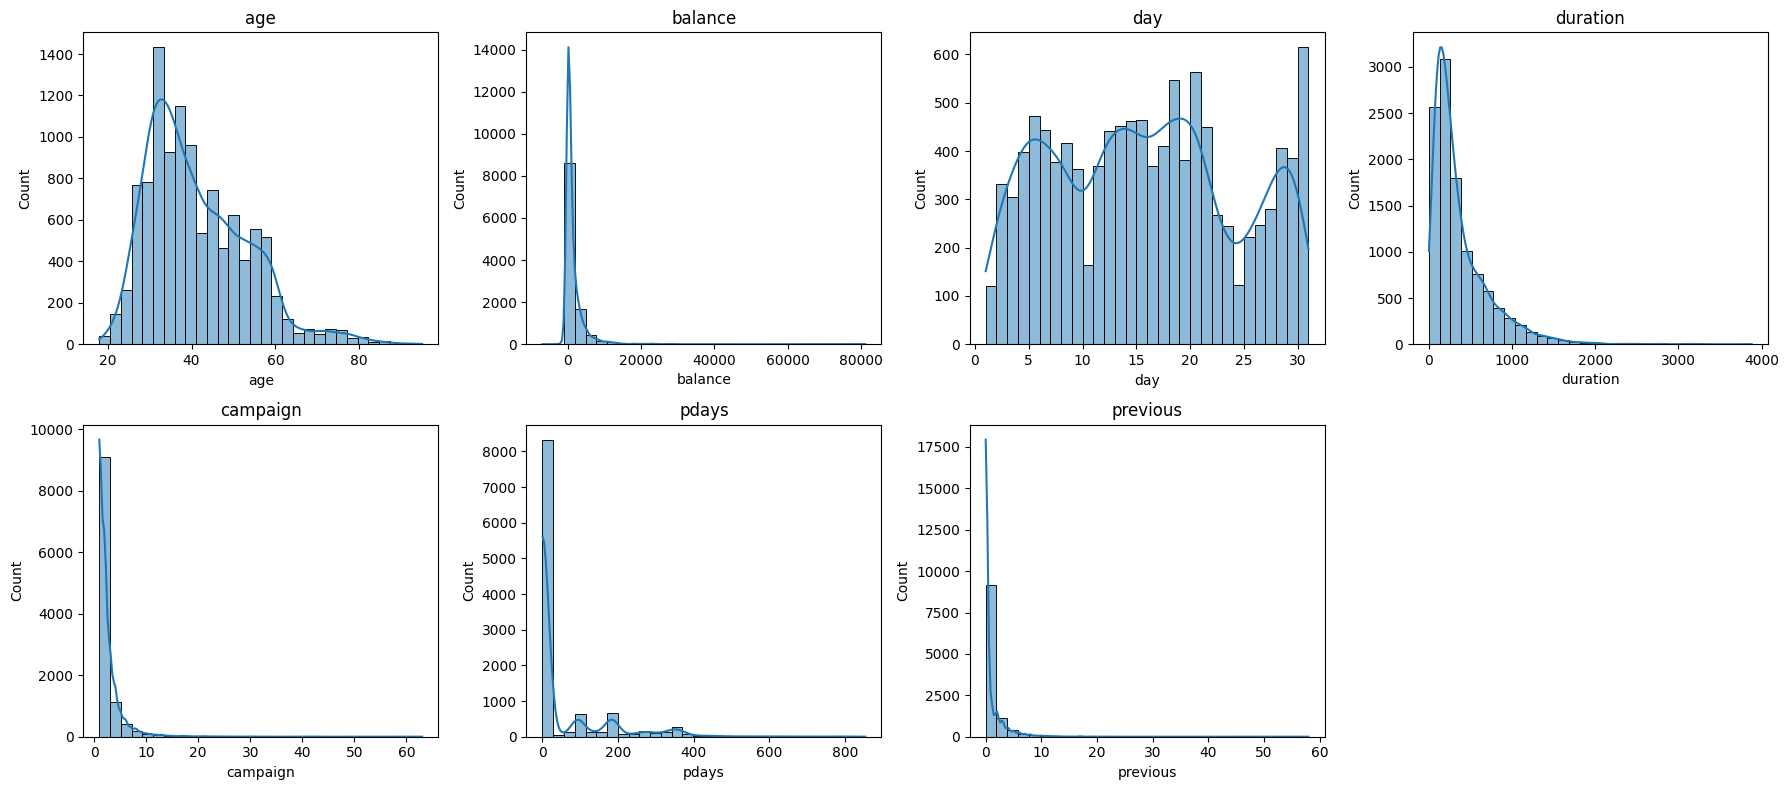

,mean,median,std,skew
age,41.20,39.0,11.91,0.87
balance,1525.91,549.0,3224.49,8.26
day,15.66,15.0,8.42,0.11
duration,372.26,255.0,347.48,2.14
campaign,2.51,2.0,2.72,5.57
pdays,52.05,0.0,108.28,2.45
previous,0.83,0.0,2.30,7.34


In [10]:
#Hər bir ədədi dəyişənin paylanması
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=clean, x=col, bins=30, kde=True, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

stats = pd.DataFrame({"mean": clean[num_cols].mean(), "median": clean[num_cols].median(),
                      "std": clean[num_cols].std(), "skew": clean[num_cols].skew()})
display(stats.round(2))

In [12]:
#IQR qaydası ilə kənar dəyərlər
rows = []
for col in num_cols:
    q1, q3 = clean[col].quantile(0.25), clean[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((clean[col] < lower) | (clean[col] > upper)).sum())
    rows.append([col, lower, upper, n_out, round(n_out / len(clean) * 100, 1)])
display(pd.DataFrame(rows, columns=["column", "lower", "upper", "n_outliers", "pct"]).round(1))

,column,lower,upper,n_outliers,pct
0,age,6.5,74.5,168,1.5
1,balance,-2251.0,4077.0,1048,9.4
2,day,-13.0,43.0,0,0.0
3,duration,-399.4,1033.6,634,5.7
4,campaign,-2.0,6.0,594,5.4
5,pdays,-26.6,44.4,2742,24.7
6,previous,-1.5,2.5,1251,11.3


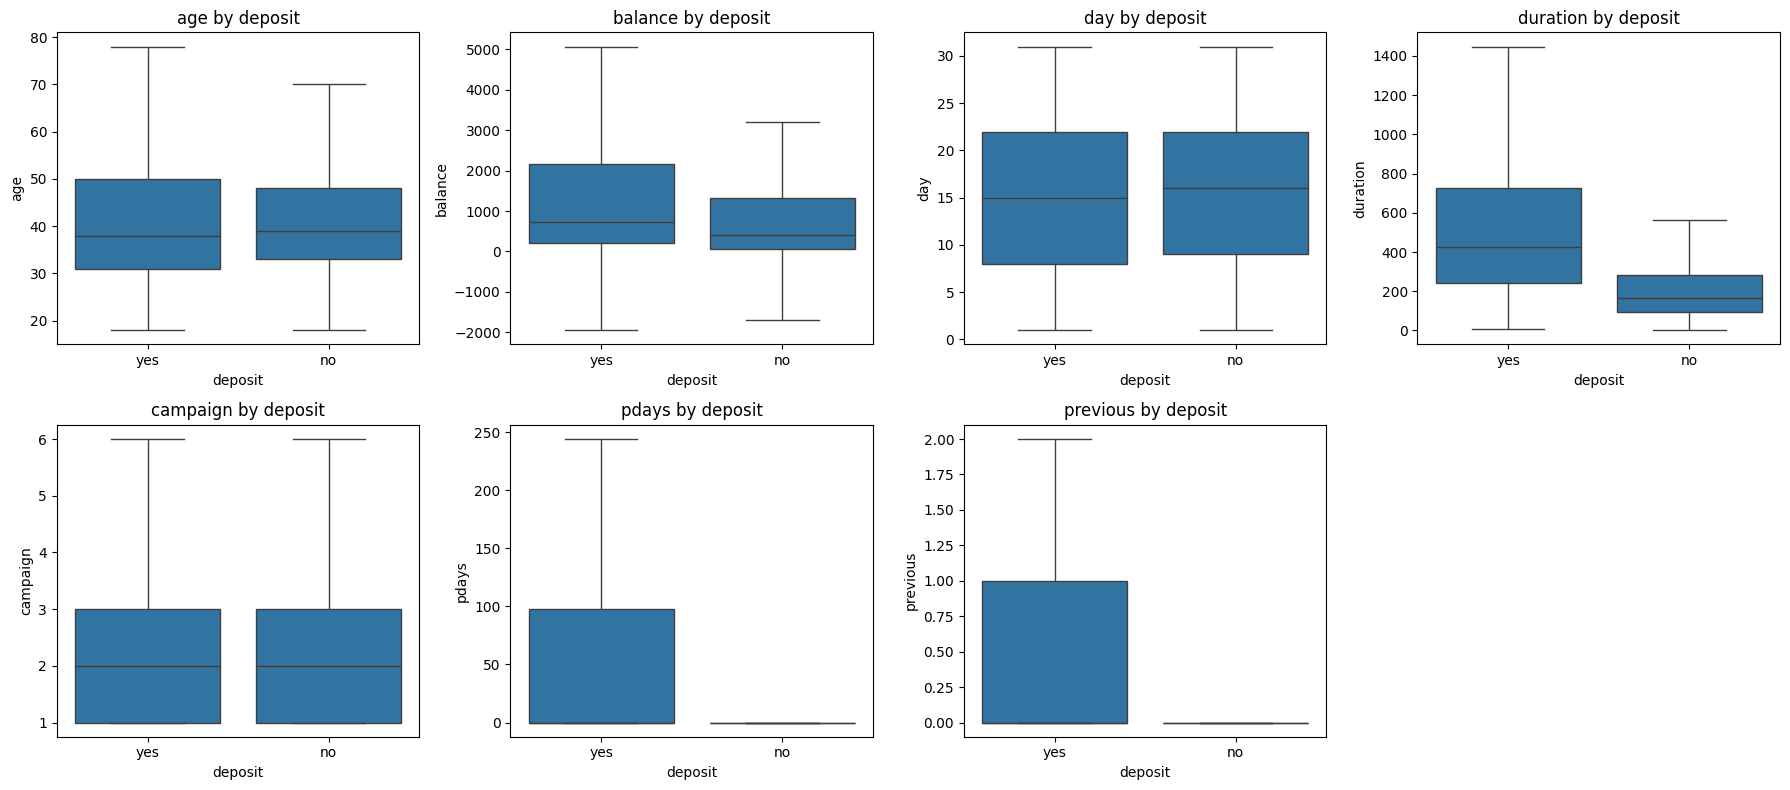

,age,balance,day,duration,campaign,pdays,previous
deposit,,,,,,,
no,39.0,414.0,16.0,163.0,2.0,0.0,0.0
yes,38.0,733.0,15.0,426.0,2.0,0.0,0.0


In [24]:
#4.4 Ədədi dəyişənlər və hədəf dəyişən (qutuların oxunaqlı qalması üçün kənar dəyərlər gizlədirik)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=clean, x=TARGET, y=col, showfliers=False, ax=ax)
    ax.set_title(f"{col} by {TARGET}")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

display(clean.groupby(TARGET)[num_cols].median().round(1))

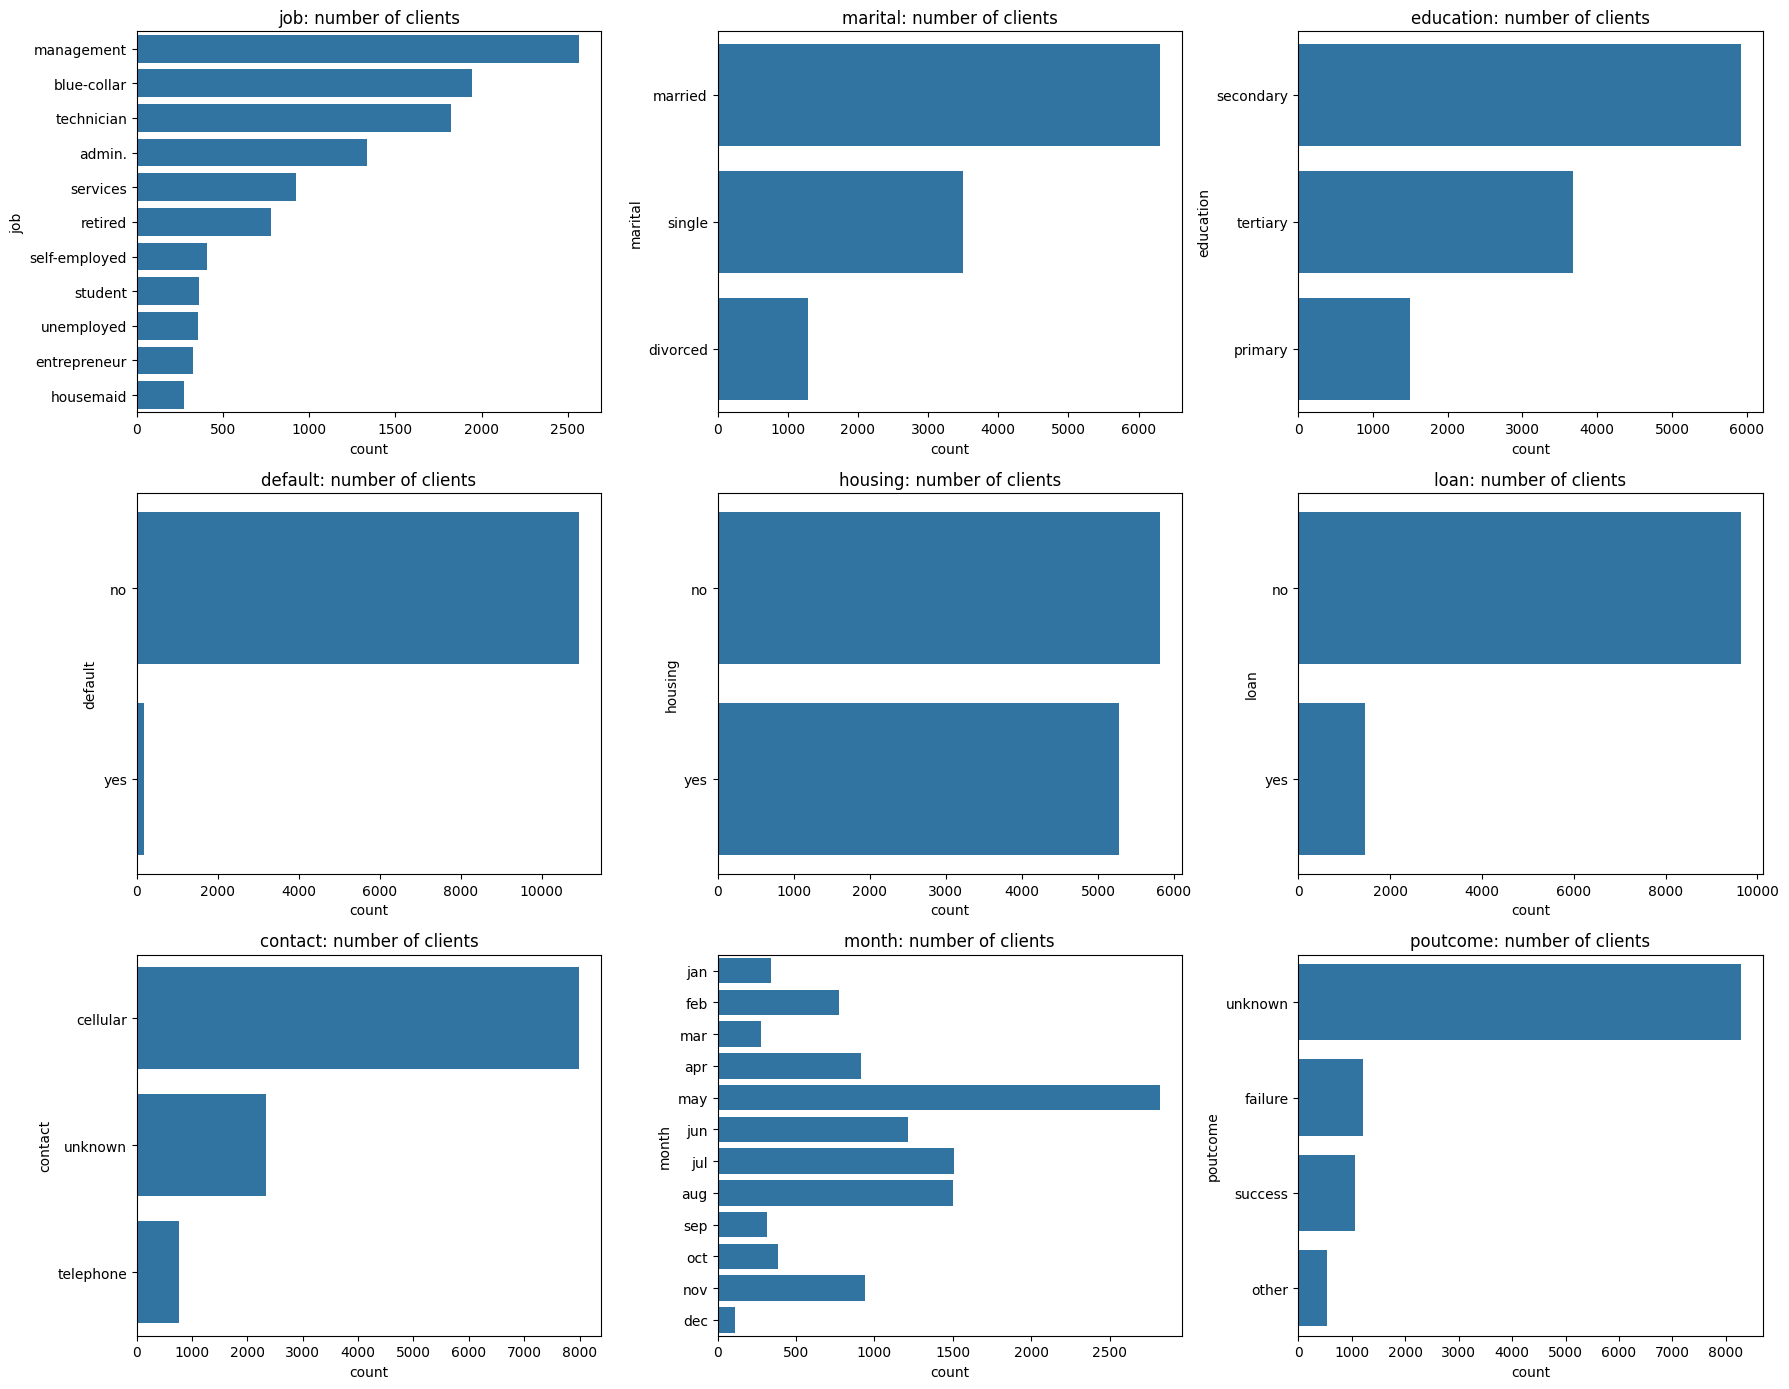

,category,column,n,pct_subscribed,pct_of_clients,small_group
0,admin.,job,1334,47.3,12.0,False
1,blue-collar,job,1944,36.4,17.5,False
2,entrepreneur,job,328,37.5,3.0,False
3,housemaid,job,274,39.8,2.5,False
4,management,job,2566,50.7,23.1,False
5,retired,job,778,66.3,7.0,False
6,self-employed,job,405,46.2,3.7,False
7,services,job,923,40.0,8.3,False
8,student,job,360,74.7,3.2,False
9,technician,job,1823,46.1,16.4,False


In [14]:
#Kateqorik dəyişənlər: hər bir kateqoriyada neçə müştəri var?
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.ravel(), cat_cols):
    order = month_order if col == "month" else clean[col].value_counts().index
    sns.countplot(data=clean, y=col, order=order, ax=ax)
    ax.set_title(f"{col}: number of clients")
plt.tight_layout()
plt.show()

summary_rows = []
for col in cat_cols:
    g = clean.groupby(col)[TARGET].agg(n="size", pct_subscribed=lambda s: (s == "yes").mean() * 100)
    g["pct_of_clients"] = g["n"] / len(clean) * 100
    g.insert(0, "column", col)
    summary_rows.append(g.reset_index().rename(columns={col: "category"}))
cat_summary = pd.concat(summary_rows, ignore_index=True)
cat_summary["small_group"] = cat_summary["n"] < 200      #kiçik qruplardan əldə edilən göstəricilər etibarsızdır
display(cat_summary.round(1))

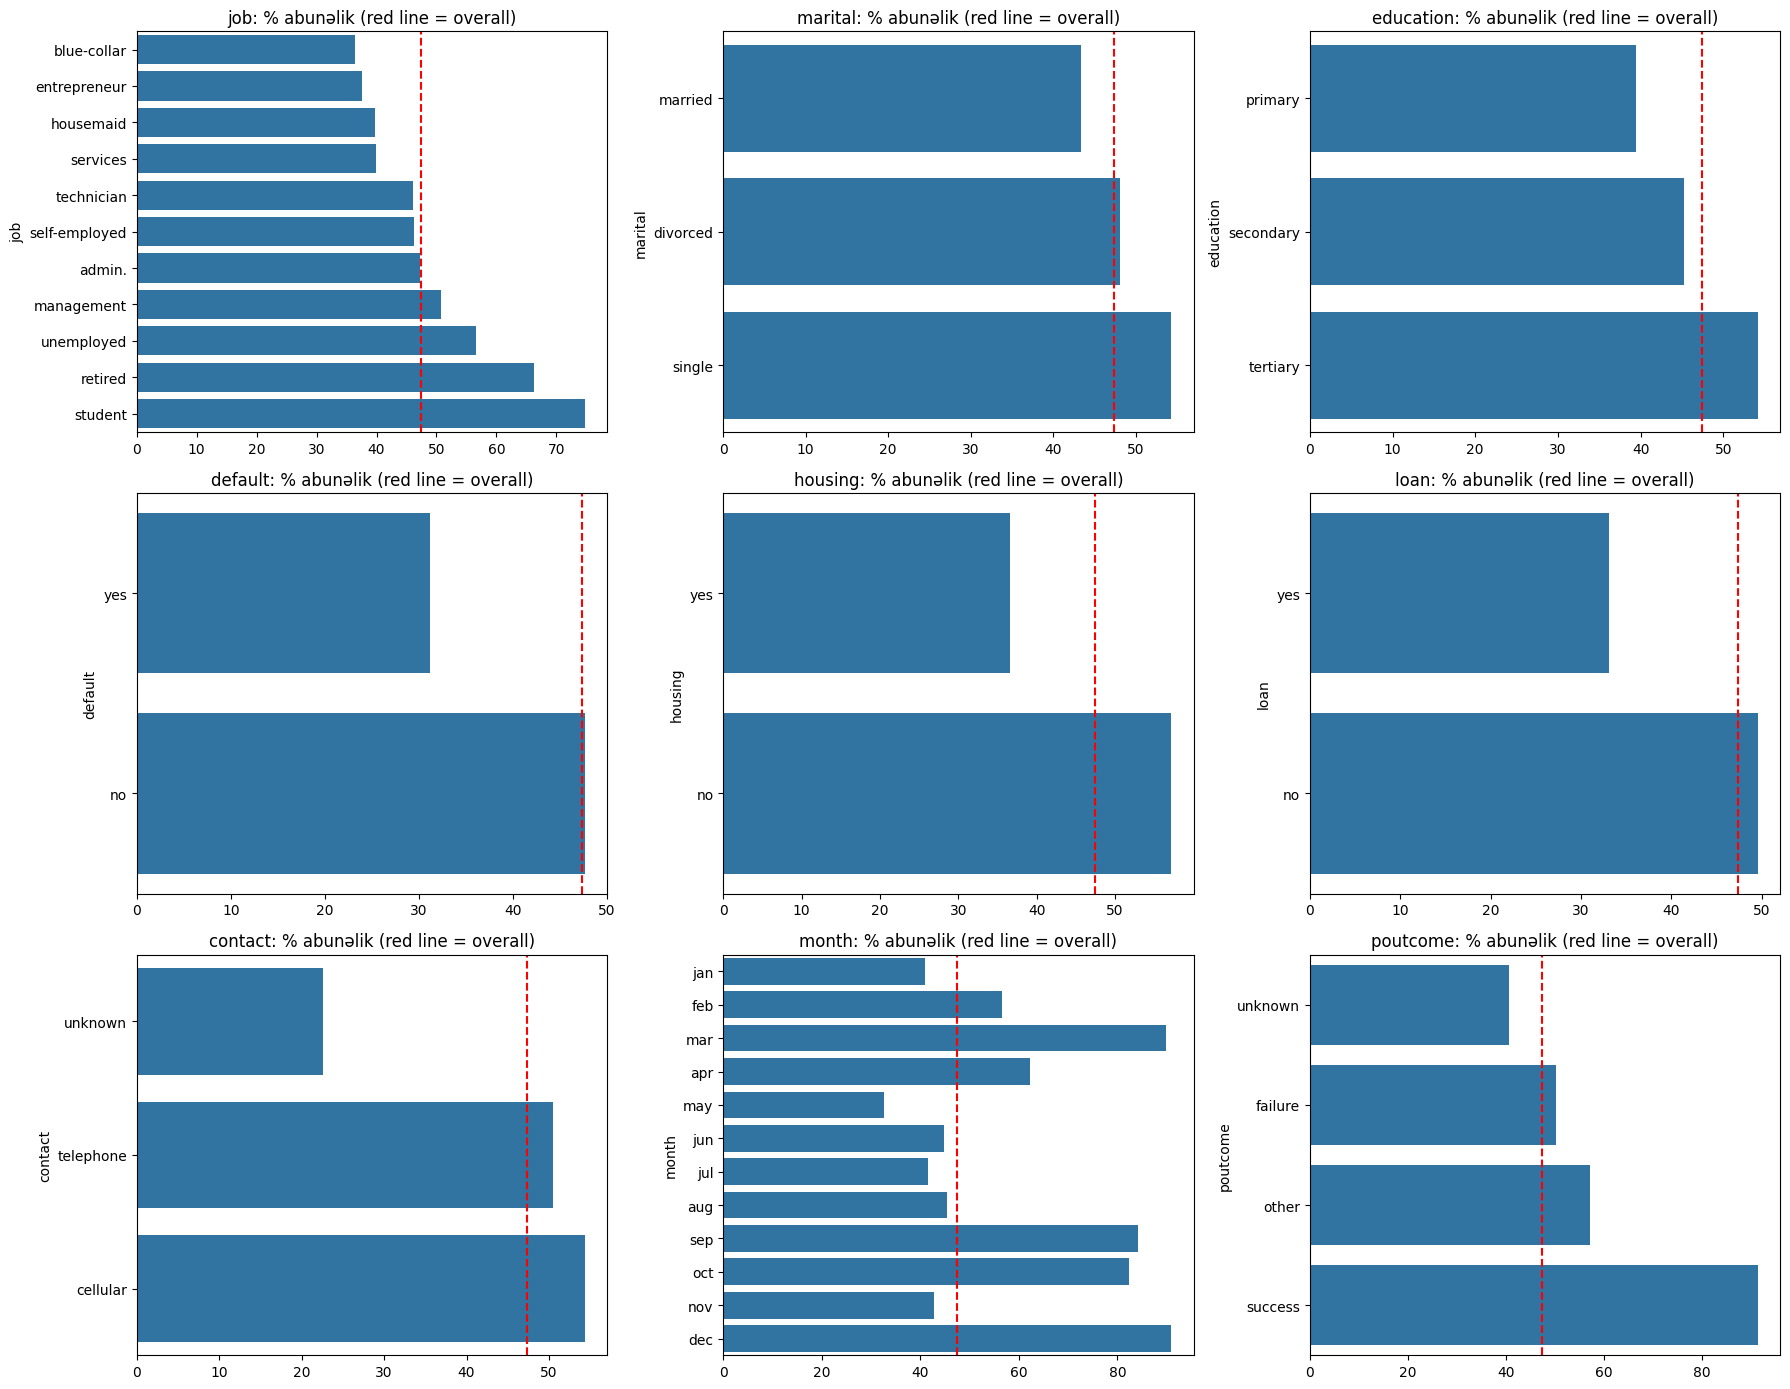

In [17]:
#Hər kateqoriya üzrə abunəlik dərəcəsi (%)
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
clean["_yes"] = (clean[TARGET] == "yes") * 100
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = clean.groupby(col)["_yes"].mean()
    rate = rate.reindex(month_order) if col == "month" else rate.sort_values()
    sns.barplot(x=rate.values, y=rate.index, orient="h", ax=ax)
    ax.axvline(clean["_yes"].mean(), color="red", linestyle="--")
    ax.set_title(f"{col}: % abunəlik (red line = overall)")
plt.tight_layout()
plt.show()
clean = clean.drop(columns="_yes")

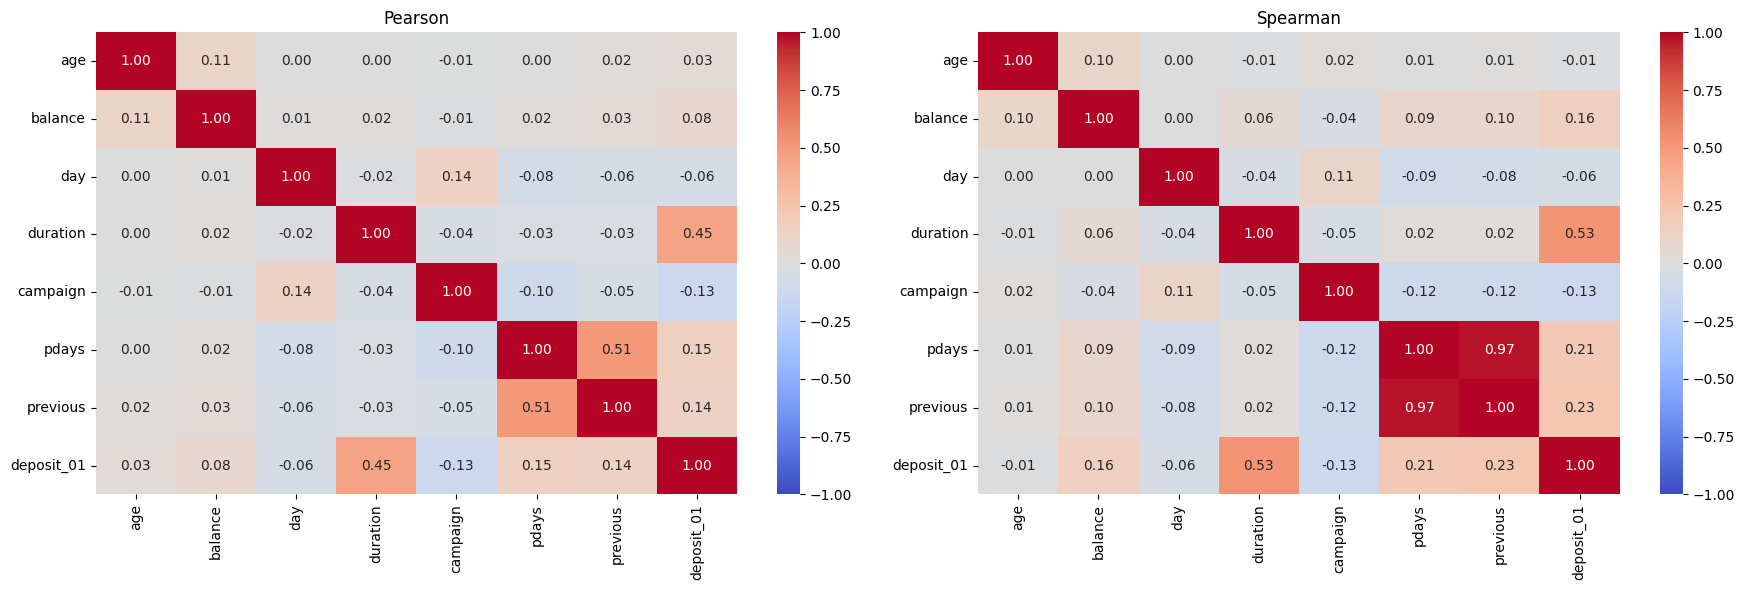

Correlation with the target (Spearman):
duration    0.527
previous    0.229
pdays       0.212
balance     0.158
age        -0.013
day        -0.058
campaign   -0.126
Name: deposit_01, dtype: float64


In [18]:
#Korrelyasiya
corr_df = clean[num_cols].copy()
corr_df["deposit_01"] = (clean[TARGET] == "yes").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(corr_df.corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_df.corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()

print("Correlation with the target (Spearman):")
print(corr_df.corr(method="spearman")["deposit_01"].drop("deposit_01").sort_values(ascending=False).round(3))

## 5.Encoding

In [19]:
model_df = clean.copy()

#binary sütunlar və hədəf
model_df[TARGET] = model_df[TARGET].map({"no": 0, "yes": 1})
for c in ["default", "housing", "loan"]:
    model_df[c] = model_df[c].map({"no": 0, "yes": 1})

#sıralanmış sütun
model_df["education"] = model_df["education"].map({"primary": 0, "secondary": 1, "tertiary": 2})

#sıralanmamış sütunlar
nominal = ["job", "marital", "contact", "poutcome", "month"]
print("Baseline (dropped) category per column:", {c: sorted(model_df[c].unique())[0] for c in nominal})
model_df = pd.get_dummies(model_df, columns=nominal, drop_first=True, dtype=int)

if DROP_DURATION:
    model_df = model_df.drop(columns="duration")


assert model_df.isna().sum().sum() == 0, "NaN created during encoding"
print("Shape after encoding:", model_df.shape)
print("Non-numeric columns left:", model_df.select_dtypes(exclude="number").columns.tolist())

Baseline (dropped) category per column: {'job': 'admin.', 'marital': 'divorced', 'contact': 'cellular', 'poutcome': 'failure', 'month': 'apr'}
Shape after encoding: (11092, 40)
Non-numeric columns left: []


## 6.Scaling'dən əvvəlki yoxlama


In [20]:
X = model_df.drop(columns=TARGET)
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Share of 'yes' in train:", round(y_train.mean(), 4), "| in test:", round(y_test.mean(), 4))

Train: (8873, 39) | Test: (2219, 39)
Share of 'yes' in train: 0.4738 | in test: 0.4736


## 7.Scaling


- **Scaling edilmiş:** yalnız kəsilməz (continuous) sütunlar (`age, balance, day, duration, campaign, pdays, previous`).
- **Scaling edilməmiş:** 0/1 sütunları (binar və "dummy" sütunlar) artıq 0-1 miqyasındadır və `education` (0-2) ordinal (ardıcıllıq bildirən) xarakter daşıyır. Hədəf dəyişəni (target) heç vaxt miqyaslanmır.
**`StandardScaler`** (z-score): `(x - mean) / std` düsturu orta qiyməti 0, standart kənarlaşmanı isə 1 edir. Alternativlər: `MinMaxScaler` (0-1 aralığına gətirir, kənar dəyərlərə qarşı çox həssasdır) və `RobustScaler` (median və IQR-dən istifadə edir; kənar dəyərlər saxlanıldığı üçün burada ən təhlükəsiz seçimdir).

In [21]:
scale_cols = [c for c in ["age", "balance", "day", "duration", "campaign", "pdays", "previous"] if c in X.columns]
scaler = {"standard": StandardScaler(), "minmax": MinMaxScaler(), "robust": RobustScaler()}[SCALER]

X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_s[scale_cols] = scaler.transform(X_test[scale_cols])

print("Scaler:", SCALER, "| scaled columns:", scale_cols)
print("\nTrain after scaling (mean should be ~0 and std ~1 for 'standard'):")
display(X_train_s[scale_cols].agg(["mean", "std", "min", "max"]).round(3))
print("Test after scaling (close to, but not exactly, 0 and 1 - this is expected):")
display(X_test_s[scale_cols].agg(["mean", "std"]).round(3))

Scaler: standard | scaled columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Train after scaling (mean should be ~0 and std ~1 for 'standard'):


,age,balance,day,duration,campaign,pdays,previous
mean,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.947,-2.575,-1.746,-1.062,-0.549,-0.480,-0.357
max,4.482,24.524,1.828,8.325,21.902,7.456,24.437


Test after scaling (close to, but not exactly, 0 and 1 - this is expected):


,age,balance,day,duration,campaign,pdays,previous
mean,-0.050,0.008,0.001,-0.013,-0.016,0.018,-0.004
std,0.968,0.961,1.013,0.968,0.922,1.031,0.904


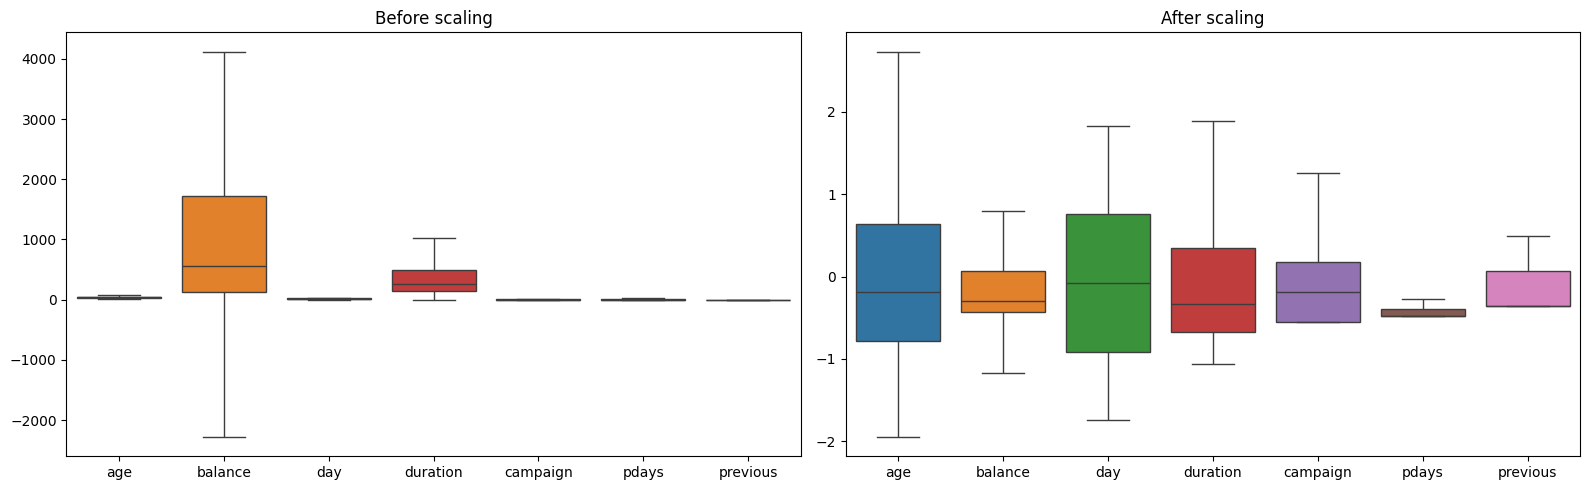

In [22]:
## Əvvəl və sonra (kənar dəyərlər olmadan)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=X_train[scale_cols], showfliers=False, ax=axes[0]); axes[0].set_title("Before scaling")
sns.boxplot(data=X_train_s[scale_cols], showfliers=False, ax=axes[1]); axes[1].set_title("After scaling")
plt.tight_layout()
plt.show()

## 8.Final

In [23]:
for name, part in [("X_train_s", X_train_s), ("X_test_s", X_test_s)]:
    print(name, part.shape,
          "| NaN:", int(part.isna().sum().sum()),
          "| non-numeric columns:", part.select_dtypes(exclude="number").shape[1])
print("Train and test have identical columns:", list(X_train_s.columns) == list(X_test_s.columns))
print("Total features:", X_train_s.shape[1])

#ən güclü korrelyasiyaya malik əlamət cütləri
corr_abs = X_train.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape, dtype=bool), k=1))
print("\nMost correlated feature pairs (|r|):")
print(upper.stack().sort_values(ascending=False).head(5).round(2))
print()

clean.to_csv("bank_cleaned.csv", index=False)
X_train_s.assign(**{TARGET: y_train}).to_csv("bank_train_ready.csv", index=False)
X_test_s.assign(**{TARGET: y_test}).to_csv("bank_test_ready.csv", index=False)
print("Saved: bank_cleaned.csv, bank_train_ready.csv, bank_test_ready.csv")

X_train_s (8873, 39) | NaN: 0 | non-numeric columns: 0
X_test_s (2219, 39) | NaN: 0 | non-numeric columns: 0
Train and test have identical columns: True
Total features: 39

Most correlated feature pairs (|r|):
pdays             poutcome_unknown    0.83
marital_married   marital_single      0.78
previous          poutcome_unknown    0.61
age               job_retired         0.57
poutcome_success  poutcome_unknown    0.56
dtype: float64

Saved: bank_cleaned.csv, bank_train_ready.csv, bank_test_ready.csv
